In [1]:
import numpy as np, basic, cosmology, local, tools_multitracer as mass, plottools as pl, constant
from matplotlib.pyplot import *
cr = rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
zmin, zmax = 0.0001, 50.
zn  = 10000
zi  = np.linspace(zmin,zmax,zn)
dz  = zi[1]-zi[0]
Hzi = basic.cosmofuncs.hubble(zi,divc=True,**local.cps)
rzi = basic.cosmofuncs.dist_comoving(zi,**local.cps)
rcmb = basic.cosmofuncs.dist_comoving([1100],**local.cps)

In [3]:
zbn  = {'euc':5,'lss':5}
bias = {'euc':np.sqrt(1.+zi),'lss':1+.84*zi}

In [4]:
zbin, dndzi, pz, frac = mass.galaxy_distribution(zi,zbn=zbn)

In [5]:
w = {}

In [6]:
w['W0'] = (1+zi)*rzi*(rcmb[0]-rzi)/rcmb[0]/Hzi
w['W1'] = cosmology.window_cib(rzi,zi,353.)/Hzi
# galaxy
N = 3
for s in ['euc','lss']:
    for zid in range(zbn[s]):
        w['W'+str(N)] = dndzi[s]*pz[s][zid]
        N += 1
print(w.keys())

dict_keys(['W0', 'W1', 'W3', 'W4', 'W5', 'W6', 'W7', 'W8', 'W9', 'W10', 'W11', 'W12'])


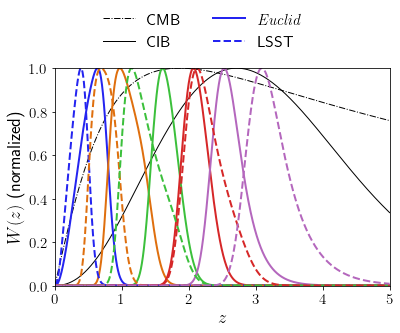

In [24]:
pl.plot_1dstyle(usetex=True,xmin=0,xmax=5.,ymin=0,ymax=1,
                xlab=r'$z$',ylab=r'$W(z)$ (normalized)',xlabsize=18,ylabsize=18,
                xticks_labsize=15,yticks_labsize=15,legend_size=16)
for I, m in enumerate(w.keys()):
    if I == 0:  co, ls, la, lw = 'k', '-.', r'CMB', 1
    if I == 1:  co, ls, la, lw = 'k', '-', r'CIB', 1
    if I >= 2 and I < zbn['euc']+2:  co, ls, lw = cr[I-2], '-', 2
    if I == 2:  la = r'{\it Euclid}'
    if I >= zbn['euc']+2 and I < zbn['euc']+zbn['lss']+2:  co, ls, lw = cr[I-2-zbn['euc']], '--', 2
    if I == zbn['euc']+2:  la = 'LSST'
    if I in [0,1,2,zbn['euc']+2]: 
        plot(zi,w[m]/np.max(w[m]),label=la,color=co,ls=ls,lw=lw)
    else:
        plot(zi,w[m]/np.max(w[m]),color=co,ls=ls,lw=lw)
legend(ncol=2,bbox_to_anchor=(0.1, 1.02))
savefig('fig_kernel.pdf',bbox_inches = 'tight', pad_inches = 0.1)